#**Feedforward Neural Network**

In [34]:
# Install required packages
!pip install GEOparse
!pip install scikit-learn
!pip install tensorflow

###**Mount path**

In [2]:
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive', force_remount=True)



Mounted at /content/drive


In [35]:
import os
# Check your Google Drive contents
drive_path = '/content/drive/My Drive/'  #driver route
# List contents of the drive root
os.listdir(drive_path)

['2)Bioinformatics_work',
 'my_projects',
 '1)Molecular_collection',
 'phd_preparation',
 'Bulk cell transcriptomic data analysis.gdoc',
 'nr14_old_drive',
 'COLLECTIONS',
 'Colab Notebooks',
 'PYTHON',
 'Status report.gslides',
 'Science project.gslides',
 'Untitled presentation.gslides',
 'REJWANA',
 'CV']

### **Load count data**

In [4]:
import gzip

geo_count_path = '/content/drive/My Drive/REJWANA/2_my_work/8_AI_ML_Deep/GSE5281_multi_omics_deep_learning/data/GSE5281_series_matrix.txt.gz'

with gzip.open(geo_count_path, 'rt') as f:
    geo_text = f.read()


In [5]:
print(geo_text[:900])  # print the first 900 characters


!Series_title	"Alzheimer's disease and the normal aged brain (steph-affy-human-433773)"
!Series_geo_accession	"GSE5281"
!Series_status	"Public on Jul 10 2006"
!Series_submission_date	"Jul 10 2006"
!Series_last_update_date	"Nov 08 2019"
!Series_pubmed_id	"17077275"
!Series_pubmed_id	"18332434"
!Series_pubmed_id	"29937276"
!Series_pubmed_id	"18270320"
!Series_summary	"Information about the genes that are preferentially expressed during the course of Alzheimer’s disease (AD) could improve our understanding of the molecular mechanisms involved in the pathogenesis of this common cause of cognitive impairment in older persons, provide new opportunities in the diagnosis, early detection, and tracking of this disorder, and provide novel targets for the discovery of interventions to treat and prevent this disorder. Information about the genes that are preferentially expressed in relationship to n


### We need to manually pre-process the count data by removing unnecessary rows.:

---



### **Load clean count data**

In [6]:
clean_count_data = open('/content/drive/My Drive/REJWANA/2_my_work/8_AI_ML_Deep/GSE5281_multi_omics_deep_learning/data/clean_GSE5281_series_matrix.txt').read()


In [7]:
print(clean_count_data[:9000])  # print the first 9000 characters


"ID_REF"	"GSM119615"	"GSM119616"	"GSM119617"	"GSM119618"	"GSM119619"	"GSM119620"	"GSM119621"	"GSM119622"	"GSM119623"	"GSM119624"	"GSM119625"	"GSM119626"	"GSM119627"	"GSM119628"	"GSM119629"	"GSM119630"	"GSM119631"	"GSM119632"	"GSM119633"	"GSM119634"	"GSM119635"	"GSM119636"	"GSM119637"	"GSM119638"	"GSM119639"	"GSM119640"	"GSM119641"	"GSM119642"	"GSM119643"	"GSM119644"	"GSM119645"	"GSM119646"	"GSM119647"	"GSM119648"	"GSM119649"	"GSM119650"	"GSM119651"	"GSM119652"	"GSM119653"	"GSM119654"	"GSM119655"	"GSM119656"	"GSM119657"	"GSM119658"	"GSM119659"	"GSM119660"	"GSM119661"	"GSM119662"	"GSM119663"	"GSM119664"	"GSM119665"	"GSM119666"	"GSM119667"	"GSM119668"	"GSM119669"	"GSM119670"	"GSM119671"	"GSM119672"	"GSM119673"	"GSM119674"	"GSM119675"	"GSM119676"	"GSM119677"	"GSM119678"	"GSM119679"	"GSM119680"	"GSM119681"	"GSM119682"	"GSM119683"	"GSM119684"	"GSM119685"	"GSM119686"	"GSM119687"	"GSM119688"	"GSM238763"	"GSM238790"	"GSM238791"	"GSM238792"	"GSM238793"	"GSM238794"	"GSM238795"	"GSM238796"	"GSM238

In [8]:
import pandas as pd
raw_metadata = pd.read_excel('/content/drive/My Drive/REJWANA/2_my_work/8_AI_ML_Deep/GSE5281_multi_omics_deep_learning/data/raw_metadata_GSE5281_sample_characteristics.xls')



In [9]:
raw_metadata.head(10)   # Shows first 10 rows


,GEO Accession:,Sample Name:,MAGE Identifier:,Sample Description:,Sample Amount:,Bio-Source Name:,Organism:,Organ/Tissue Type:,Organ Region:,Cell Type:,Ethnicity:,Developmental Stage:,Disease State:,Sex:,Genetic Variation:,Age:
0,GSM119615,EC control 1,arrayconsortium.tgen.org::biosample.433887,AD control,10 ug,EC control 1,Human,brain,Entorhinal Cortex,layer III neurons,Caucasian,Adult,normal,male,None,63 years
1,GSM119616,EC control 2,arrayconsortium.tgen.org::biosample.433901,AD control,10 ug,EC control 2,Human,brain,Entorhinal Cortex,layer III neurons,Caucasian,Adult,normal,male,None,85 years
2,GSM119617,EC control 3,arrayconsortium.tgen.org::biosample.433915,AD control,10 ug,EC control 3,Human,brain,Entorhinal Cortex,layer III neurons,Caucasian,Adult,normal,male,None,80 years
3,GSM119618,EC control 4,arrayconsortium.tgen.org::biosample.433929,AD control,10 ug,EC control 4,Human,brain,Entorhinal Cortex,layer III neurons,Caucasian,Adult,normal,male,None,80 years
4,GSM119619,EC control 5,arrayconsortium.tgen.org::biosample.433943,AD control,10 ug,EC control 5,Human,brain,Entorhinal Cortex,layer III neurons,Caucasian,Adult,normal,female,None,102 years
5,GSM119620,EC control 6,arrayconsortium.tgen.org::biosample.433957,AD control,10 ug,EC control 6,Human,brain,Entorhinal Cortex,layer III neurons,Caucasian,Adult,normal,male,None,79 years
6,GSM119621,EC control 7,arrayconsortium.tgen.org::biosample.433971,AD control,10 ug,EC control 7,Human,brain,Entorhinal Cortex,layer III neurons,Caucasian,Adult,normal,male,None,76 years
7,GSM119622,EC control 8,arrayconsortium.tgen.org::biosample.433985,AD control,10 ug,EC control 8,Human,brain,Entorhinal Cortex,layer III neurons,Caucasian,Adult,normal,male,None,83 years
8,GSM119623,EC control 9,arrayconsortium.tgen.org::biosample.433999,AD control,10 ug,EC control 9,Human,brain,Entorhinal Cortex,layer III neurons,Caucasian,Adult,normal,male,None,79 years
9,GSM119624,EC control 10,arrayconsortium.tgen.org::biosample.434013,AD control,10 ug,EC control 10,Human,brain,Entorhinal Cortex,layer III neurons,Caucasian,Adult,normal,female,None,88 years


In [10]:
clean_metadata = pd.read_excel('/content/drive/My Drive/REJWANA/2_my_work/8_AI_ML_Deep/GSE5281_multi_omics_deep_learning/data/processed_metadata_GSE5281.xls')


In [11]:
clean_metadata.head(10)   # Shows first 10 rows

,GEO Accession:,Sample Name:,Sample Description:,Organ Region:,Cell Type:,Disease State:,Sex:,Age:
0,GSM119615,EC control 1,AD control,Entorhinal Cortex,layer III neurons,normal,male,63 years
1,GSM119616,EC control 2,AD control,Entorhinal Cortex,layer III neurons,normal,male,85 years
2,GSM119617,EC control 3,AD control,Entorhinal Cortex,layer III neurons,normal,male,80 years
3,GSM119618,EC control 4,AD control,Entorhinal Cortex,layer III neurons,normal,male,80 years
4,GSM119619,EC control 5,AD control,Entorhinal Cortex,layer III neurons,normal,female,102 years
5,GSM119620,EC control 6,AD control,Entorhinal Cortex,layer III neurons,normal,male,79 years
6,GSM119621,EC control 7,AD control,Entorhinal Cortex,layer III neurons,normal,male,76 years
7,GSM119622,EC control 8,AD control,Entorhinal Cortex,layer III neurons,normal,male,83 years
8,GSM119623,EC control 9,AD control,Entorhinal Cortex,layer III neurons,normal,male,79 years
9,GSM119624,EC control 10,AD control,Entorhinal Cortex,layer III neurons,normal,female,88 years


Here,
clean_count_data = gene expression data as a .txt file (read into a variable)

clean_metadata = processed metadata loaded as a DataFrame from Excel


In [12]:

txt_path = '/content/drive/My Drive/REJWANA/2_my_work/8_AI_ML_Deep/GSE5281_multi_omics_deep_learning/data/clean_GSE5281_series_matrix.txt'

# Skip metadata lines (usually starting with '!')
expr_df = pd.read_csv(txt_path, sep='\t', comment='!', index_col=0)

# Transpose: samples = rows, genes = columns
X_df = expr_df.T
print("Expression shape (samples x genes):", X_df.shape)
X_df.head()



Expression shape (samples x genes): (161, 54675)


ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM119615,693.97330,9.755318,13.346846,173.09245,52.616950,67.753624,209.41220,10.765010,10.559881,38.878853,...,4114.2500,4114.5767,13951.371,9590.616,1821.608200,46.302326,279.892550,9.149380,5.280712,7.380331
GSM119616,807.14514,19.052270,18.217276,289.31540,110.375984,96.780740,470.43307,3.834024,27.871660,73.023575,...,5400.4585,4465.0913,19854.145,14496.598,21.710300,5.705804,3.477558,1.878478,3.469311,3.117868
GSM119617,1722.62500,13.060389,97.425470,537.18280,99.021736,76.282050,908.26636,7.970618,121.391370,17.437328,...,11152.8860,8695.5380,47580.984,33593.055,36.736942,30.422820,6.315493,8.501900,23.347307,67.153730
GSM119618,1668.05750,14.652245,98.197945,496.34656,17.306772,189.819600,1029.78850,3.469380,48.153168,10.587775,...,14431.4080,10365.0530,45601.290,33553.914,5.882349,6.936473,17.975550,6.254964,58.965458,9.972722
GSM119619,2231.29690,138.676830,106.468440,477.86517,628.816160,276.476560,1366.78370,11.245625,3.137640,147.823200,...,15043.5030,14511.4820,50365.547,37182.836,13262.363000,448.497340,3133.012200,29.297655,28.627400,2.507613


###loading and processing the gene expression count data

In [13]:
import pandas as pd

count_data_txt = '/content/drive/My Drive/REJWANA/2_my_work/8_AI_ML_Deep/GSE5281_multi_omics_deep_learning/data/clean_GSE5281_series_matrix.txt'

count_data_csv = pd.read_csv(count_data_txt, sep='\t', comment='!', index_col=0)

print("Expression shape (samples x genes):", count_data_csv.shape)

# Transpose the data (samples as rows, genes as columns)
X_df = count_data_csv.T
print("Transposed shape (samples x genes):", X_df.shape)

X_df.head(10)


Expression shape (samples x genes): (54675, 161)
Transposed shape (samples x genes): (161, 54675)


ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM119615,693.97330,9.755318,13.346846,173.09245,52.616950,67.753624,209.41220,10.765010,10.559881,38.878853,...,4114.2500,4114.5767,13951.371,9590.616,1821.608200,46.302326,279.892550,9.149380,5.280712,7.380331
GSM119616,807.14514,19.052270,18.217276,289.31540,110.375984,96.780740,470.43307,3.834024,27.871660,73.023575,...,5400.4585,4465.0913,19854.145,14496.598,21.710300,5.705804,3.477558,1.878478,3.469311,3.117868
GSM119617,1722.62500,13.060389,97.425470,537.18280,99.021736,76.282050,908.26636,7.970618,121.391370,17.437328,...,11152.8860,8695.5380,47580.984,33593.055,36.736942,30.422820,6.315493,8.501900,23.347307,67.153730
GSM119618,1668.05750,14.652245,98.197945,496.34656,17.306772,189.819600,1029.78850,3.469380,48.153168,10.587775,...,14431.4080,10365.0530,45601.290,33553.914,5.882349,6.936473,17.975550,6.254964,58.965458,9.972722
GSM119619,2231.29690,138.676830,106.468440,477.86517,628.816160,276.476560,1366.78370,11.245625,3.137640,147.823200,...,15043.5030,14511.4820,50365.547,37182.836,13262.363000,448.497340,3133.012200,29.297655,28.627400,2.507613
GSM119620,990.54100,7.186742,98.710520,355.09200,105.254600,130.088290,624.67926,22.197855,8.126172,24.068861,...,11302.5790,9113.8880,36254.090,28733.100,14.434994,28.413843,7.277436,3.096380,5.922369,4.711027
GSM119621,1396.82420,10.170890,164.326660,467.56790,142.269180,131.513340,1589.27660,7.773280,73.906970,24.427702,...,25951.8800,16733.5250,70227.280,56858.520,10.715485,11.918980,69.250970,10.467917,46.583836,10.538683
GSM119622,1026.05650,34.056934,46.306164,294.58328,123.016136,109.670810,858.42300,7.727498,9.745271,58.589240,...,12030.6390,9510.9490,36646.867,27644.191,5.828534,3.923356,27.650482,8.064908,7.823233,1.971074
GSM119623,736.77030,7.829473,35.067910,224.52406,183.396910,63.197280,643.09500,4.196418,6.104734,84.349400,...,8546.7220,7087.4316,31389.120,23356.656,10.722560,14.250128,18.748734,8.410315,17.401910,18.304653
GSM119624,938.81710,40.235332,72.864900,298.28473,180.814250,78.263855,412.51947,12.778767,16.480728,36.493810,...,8597.4590,7381.8804,27935.940,21766.600,8.189967,6.387569,2.100605,3.726756,5.499322,2.633168


###Merge with Metadata (to get labels)

In [14]:
print(clean_metadata.columns)


Index(['GEO Accession:', 'Sample Name:', 'Sample Description:',
       'Organ Region:', 'Cell Type:', 'Disease State:', 'Sex:', 'Age:'],
      dtype='object')


In [15]:
from sklearn.preprocessing import StandardScaler

merged_df = X_df.merge(clean_metadata, left_index=True, right_on='GEO Accession:')

metadata_cols = ['GEO Accession:', 'Disease State:']
gene_columns = [col for col in merged_df.columns if col not in metadata_cols]

X = merged_df[gene_columns].copy()
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Extract labels (Alzheimer’s = 1, Normal = 0)
y = merged_df['Disease State:'].apply(lambda x: 1 if 'alzheimer' in str(x).lower() else 0).values

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print(" X_scaled shape:", X_scaled.shape)
print("y shape:", y.shape)


 X_scaled shape: (161, 54681)
y shape: (161,)


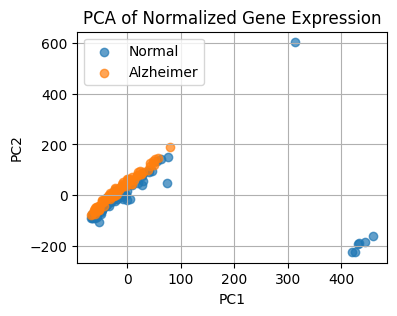

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot the PCA result
plt.figure(figsize=(4, 3))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], label='Normal', alpha=0.7)
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], label='Alzheimer', alpha=0.7)
plt.title('PCA of Normalized Gene Expression')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()


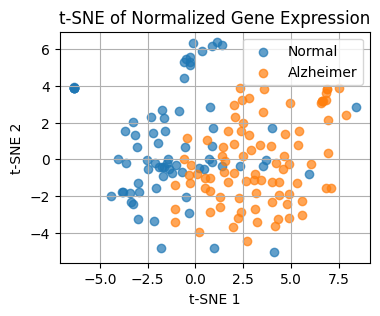

In [37]:
from sklearn.manifold import TSNE

# Run t-SNE on a sample of the data
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(4, 3))
plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1], label='Normal', alpha=0.7)
plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1], label='Alzheimer', alpha=0.7)
plt.title('t-SNE of Normalized Gene Expression')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True)
plt.show()


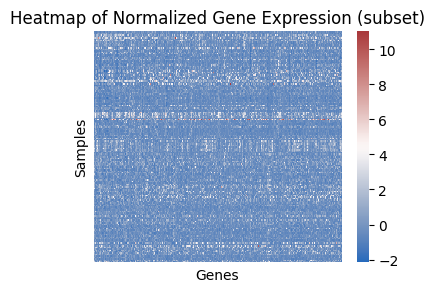

In [38]:
import seaborn as sns


subset = X_scaled[:250, :250]  # First 250 samples & 250 genes

plt.figure(figsize=(4, 3))
sns.heatmap(subset, cmap='vlag', xticklabels=False, yticklabels=False)
plt.title('Heatmap of Normalized Gene Expression (subset)')
plt.xlabel('Genes')
plt.ylabel('Samples')
plt.show()


###Split data after normalization

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


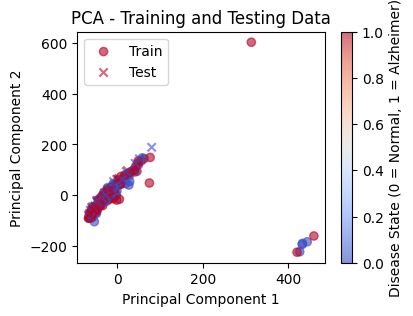

In [32]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca = X_pca[:len(X_train)], X_pca[len(X_train):]


plt.figure(figsize=(4, 3))


plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', label='Train', alpha=0.6)


plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', marker='x', label='Test', alpha=0.6)


plt.title('PCA - Training and Testing Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.colorbar(label='Disease State (0 = Normal, 1 = Alzheimer)')

# Show the plot
plt.show()


#**Feedforward Neural Network**


In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Define the Feedforward Neural Network
model_fnn = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),  # Input layer
    Dropout(0.5),
    Dense(64, activation='relu'),                                # Hidden layer
    Dropout(0.5),
    Dense(1, activation='sigmoid')                               # Output layer for binary classification
])

# 2. Compile the model
model_fnn.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# 3. View model architecture
model_fnn.summary()

# 4. Train the model
history_fnn = model_fnn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     6,999,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,007,617 (26.73 MB)

 Trainable params: 7,007,617 (26.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.6641 - loss: 1.5237 - val_accuracy: 0.9615 - val_loss: 0.3151
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6683 - loss: 3.6900 - val_accuracy: 0.8846 - val_loss: 1.5593
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.7814 - loss: 3.7669 - val_accuracy: 0.8846 - val_loss: 1.1554
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9241 - loss: 0.9723 - val_accuracy: 0.8846 - val_loss: 0.4878
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.8779 - loss: 3.9484 - val_accuracy: 0.9615 - val_loss: 0.0397
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.8902 - loss: 1.7506 - val_accuracy: 0.9615 - val_loss: 0.1419
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.9019 - loss: 1.5040 - val_accuracy: 0.8846 - val_loss: 2.5394
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.9301 - loss: 0.7997 - val_accuracy: 0.8846 - val_loss: 

### Evaluate the model

In [40]:
test_loss, test_acc = model_fnn.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9081 - loss: 2.8950
Test accuracy: 0.9091
Test loss: 2.8651


###Plot the training and validation loss/accuracy

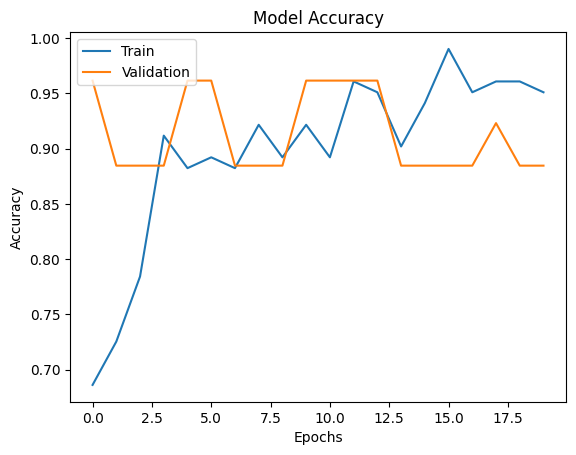

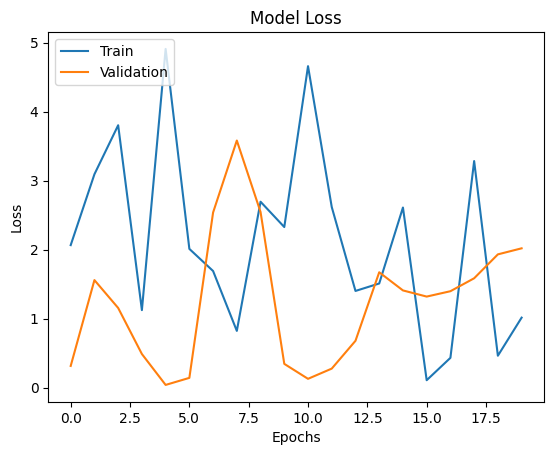

In [41]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history_fnn.history['accuracy'])
plt.plot(history_fnn.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history_fnn.history['loss'])
plt.plot(history_fnn.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


###Make predictions

In [42]:
# predictions on the test data
y_pred = model_fnn.predict(X_test)

y_pred_binary = (y_pred > 0.5).astype(int)  # Convert the predictions to binary (0 or 1) based on a threshold (0.5)

from sklearn.metrics import confusion_matrix, classification_report  # Compare the predicted values with actual labels

conf_matrix = confusion_matrix(y_test, y_pred_binary)   # Confusion Matrix
print(f"Confusion Matrix:\n{conf_matrix}")

class_report = classification_report(y_test, y_pred_binary)  # Classification Report
print(f"Classification Report:\n{class_report}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Confusion Matrix:
[[14  1]
 [ 2 16]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.94      0.89      0.91        18

    accuracy                           0.91        33
   macro avg       0.91      0.91      0.91        33
weighted avg       0.91      0.91      0.91        33



###**ROC Curve**

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


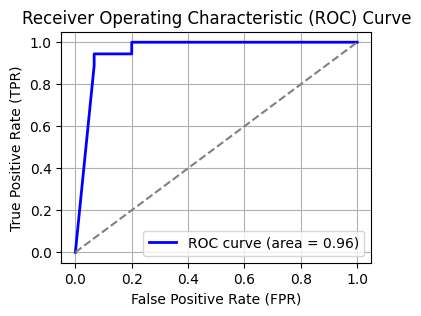

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


y_pred_prob = model_fnn.predict(X_test)  # Get predicted probabilities (not binary predictions)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) #  Calculate the ROC curve

roc_auc = auc(fpr, tpr) # Calculate the Area Under the Curve (AUC)

# Plot the ROC curve
plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, color='b', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (no discrimination)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [44]:
# Save the model
model_fnn.save('/content/drive/My Drive/REJWANA/2_my_work/8_AI_ML_Deep/GSE5281_multi_omics_deep_learning/saved_model_fnn.h5')


In [45]:
##Loaded model later
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('/content/drive/My Drive/REJWANA/2_my_work/8_AI_ML_Deep/GSE5281_multi_omics_deep_learning/saved_model_fnn.h5')

# Check the model summary
loaded_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     6,999,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,007,619 (26.73 MB)

 Trainable params: 7,007,617 (26.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)